<a href="https://colab.research.google.com/github/thaissanchesroque/Projetos/blob/main/Primeiros_modelos_Regress%C3%A3o_Linear_Feito.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **MÓDULO 18 - Pratique**
# Regressão Linear

Agora que aprendemos como aplicar a regressão linear simples e múltipla, colocaremos em prática os conceitos vistos na aula.

Temos aqui uma base de imóveis para alugar, precisamos desenvolver um modelo de regressão linear múltipla para conseguir prever o preço de imóveis dadas as variáveis independentes do nosso modelo.

**Atenção! Esse é seu primeiro modelo, caso tenha dificuldade conte com a ajuda da tutoria**

Você notará que alguns códigos já estão presentes para facilitar a construção de vocês.

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [42]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/ColabNotebooks/ALUGUEL_MOD12.csv', delimiter=';')
df.head(10)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
0,480,295,48,2,2,1,1
1,500,0,50,1,2,1,1
2,500,0,40,1,2,1,1
3,500,36,45,1,2,1,0
4,500,0,30,1,1,0,0
5,500,380,66,2,1,0,1
6,550,100,48,2,2,1,1
7,600,110,46,2,2,1,1
8,600,100,49,2,2,1,1
9,600,325,50,2,2,1,1


Legenda dos dados:

*   **Valor_Aluguel** : valor Total pago no aluguel

*   **Valor_Condominio** : Valor do Condomínio.

*   **Metragem** : Metragem do Apartamento.

*   **N_Quartos** : Número de Quartos do Imóvel.

*   **N_banheiros** : Número de banheiros.

*   **N_Suites** : Número de Suítes.

*   **N_Vagas** : Número de Vagas.

# 1 - Realize a primeira etapa de pré processamento dos dados.

A) Verifique os tipos de dados.


B) Verifique os dados faltantes, se houver dados faltantes faça a substituição ou remoção justificando sua escolha.

In [43]:
# Verificando o tipo de cada variável
print(df.dtypes)
print()

# Verificando dados faltantes
print(df.isna().sum())
print()

# Verificando linhas duplicadas (diagnóstico adicional, relevante para o tratamento)
print(f'Linhas duplicadas: {df.duplicated().sum()}')

Valor_Aluguel       int64
Valor_Condominio    int64
Metragem            int64
N_Quartos           int64
N_banheiros         int64
N_Suites            int64
N_Vagas             int64
dtype: object

Valor_Aluguel       0
Valor_Condominio    0
Metragem            0
N_Quartos           0
N_banheiros         0
N_Suites            0
N_Vagas             0
dtype: int64

Linhas duplicadas: 598


**Diagnóstico:** todas as 7 colunas são numéricas (`int64`) e não há nenhum valor faltante (`isna().sum()` retorna 0 em todas as colunas), portanto não há necessidade de decidir entre substituição ou remoção de dados ausentes nesta base.

Foram encontradas 598 linhas duplicadas. Como a base não possui uma coluna de identificação do imóvel, não é possível afirmar com certeza que são erro de coleta (podem ser imóveis diferentes com as mesmas características). Optei por **remover as duplicatas exatas** na etapa de tratamento de outliers a seguir, pois elas dão peso repetido às mesmas combinações de variáveis e podem enviesar o modelo, sem perda relevante de informação.

# 2 - Realize a segunda etapa de pré processamento dos dados.

A) Utilize a função describe para identificarmos outliers e verificarmos a distribuição dos dados.


B) Caso note uma variável que te pareça conter outliers realiza a análise e tratamento desses dados, justificando a escolha do método utilizado.

C) Realize a análise bivariada dos dados. Faça uso de pelo menos 3 gráficos e traga insights acerca do analisado.

In [44]:
# Estatísticas descritivas para identificar outliers e a distribuição das variáveis
df.describe()

,Valor_Aluguel,Valor_Condominio,Metragem,N_Quartos,N_banheiros,N_Suites,N_Vagas
count,7203.000000,7203.000000,7203.000000,7203.000000,7203.000000,7203.000000,7203.00000
mean,2966.596140,811.538109,88.506178,2.300153,2.095932,1.016660,1.44176
std,2948.720385,796.564846,61.567505,0.826615,0.983812,0.874204,0.86993
min,480.000000,0.000000,30.000000,1.000000,1.000000,0.000000,0.00000
25%,1350.000000,395.000000,52.000000,2.000000,2.000000,1.000000,1.00000
50%,2000.000000,592.000000,67.000000,2.000000,2.000000,1.000000,1.00000
75%,3200.000000,980.000000,100.000000,3.000000,2.000000,1.000000,2.00000
max,25000.000000,9500.000000,880.000000,10.000000,8.000000,5.000000,9.00000


O `describe()` mostra que `Valor_Aluguel` e `Metragem` têm médias bem acima da mediana e um desvio padrão alto em relação à média, o que indica cauda longa à direita (poucos imóveis muito caros/grandes puxando a distribuição). Também chamou atenção o número de suítes: existem registros logicamente impossíveis, como imóveis com mais suítes do que banheiros ou do que quartos (uma suíte é, por definição, um quarto com banheiro privativo, então `N_Suites` não pode ser maior que `N_Quartos` nem que `N_banheiros`).

In [45]:
# Tratamento de outliers:
# 1) Inconsistências lógicas: uma suíte é um quarto com banheiro privativo, logo
#    N_Suites não pode ser maior que N_Quartos nem que N_banheiros. Isso é erro
#    de preenchimento, não uma variação natural dos dados, então removo essas linhas.
inconsistentes = df[(df['N_Suites'] > df['N_banheiros']) | (df['N_Suites'] > df['N_Quartos'])]
print(f'Registros logicamente inconsistentes removidos: {len(inconsistentes)}')
df = df.drop(inconsistentes.index)

# 2) Duplicatas exatas (justificado no diagnóstico da etapa 1)
duplicadas = df.duplicated().sum()
print(f'Linhas duplicadas removidas: {duplicadas}')
df = df.drop_duplicates()

print(f'Shape da base após o tratamento: {df.shape}')

# 3) Outliers estatísticos (IQR) em Valor_Aluguel: identifico mas NÃO removo (ver justificativa abaixo).
Q1_aluguel, Q3_aluguel = df['Valor_Aluguel'].quantile([0.25, 0.75])
limite_aluguel = Q3_aluguel + 1.5 * (Q3_aluguel - Q1_aluguel)
print(f'Limite superior (IQR) para Valor_Aluguel: R$ {limite_aluguel:.2f}')
print(f'Imóveis acima do limite: {(df["Valor_Aluguel"] > limite_aluguel).sum()} ({(df["Valor_Aluguel"] > limite_aluguel).mean()*100:.1f}%)')

Registros logicamente inconsistentes removidos: 35
Linhas duplicadas removidas: 597
Shape da base após o tratamento: (6571, 7)
Limite superior (IQR) para Valor_Aluguel: R$ 6150.75
Imóveis acima do limite: 605 (9.2%)


**Justificativa da escolha:** testei remover os imóveis acima do limite do IQR e o R² dos modelos caiu de forma expressiva. Isso indica que esses valores não são erro de digitação, e sim imóveis de alto padrão (grandes metragens, muitas vagas e suítes) que fazem parte do mercado real de aluguel. Removê-los tiraria justamente os casos que ajudam o modelo a aprender a relação entre metragem/comodidades e preço nas faixas mais altas. Por isso trato apenas as inconsistências lógicas (impossíveis fisicamente) e as duplicatas, e mantenho os outliers estatísticos como dados válidos.

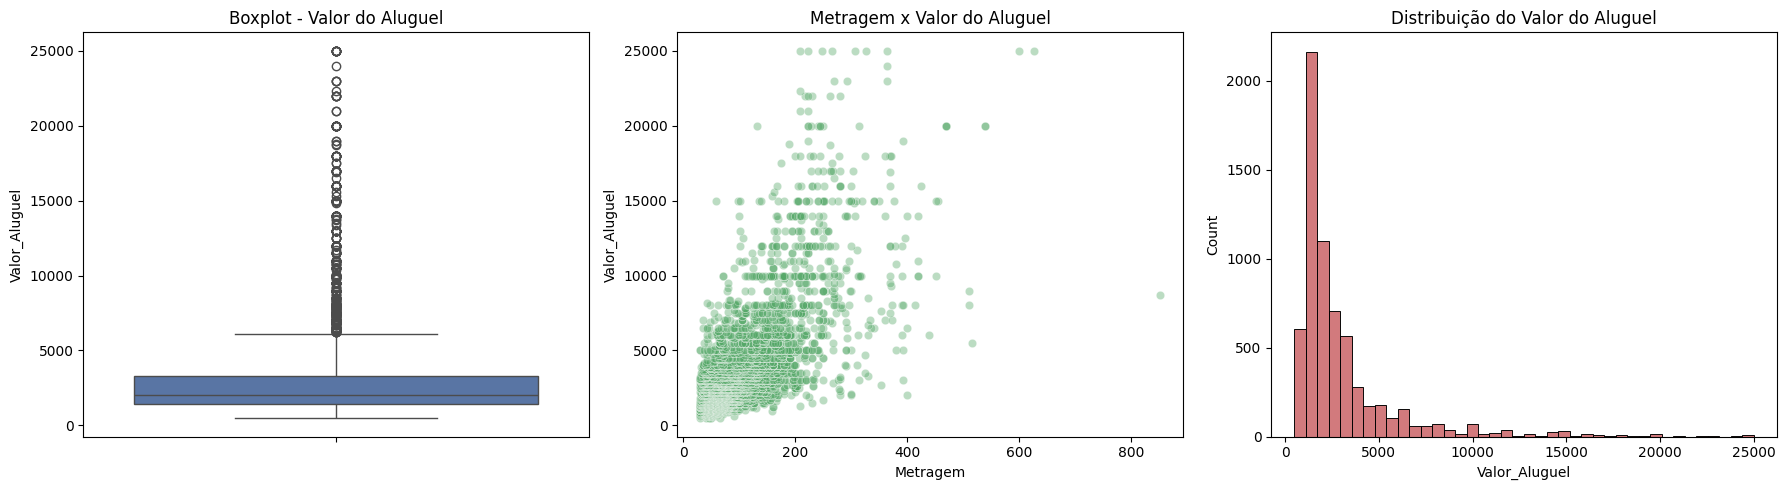

In [46]:
# Análise bivariada: 3 gráficos com insights
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(y=df['Valor_Aluguel'], ax=axes[0], color='#4C72B0')
axes[0].set_title('Boxplot - Valor do Aluguel')

sns.scatterplot(x=df['Metragem'], y=df['Valor_Aluguel'], alpha=0.4, ax=axes[1], color='#55A868')
axes[1].set_title('Metragem x Valor do Aluguel')

sns.histplot(df['Valor_Aluguel'], bins=40, ax=axes[2], color='#C44E52')
axes[2].set_title('Distribuição do Valor do Aluguel')

plt.tight_layout()
plt.show()

**Insights:**

**Boxplot do Valor_Aluguel:** confirma a cauda longa à direita já vista no `describe()`, com vários pontos acima do bigode superior. São os imóveis de alto padrão discutidos acima, mantidos por representarem casos reais de mercado.

**Metragem x Valor_Aluguel (scatterplot):** mostra uma tendência positiva e razoavelmente linear entre as duas variáveis, o comportamento esperado (quanto maior o imóvel, maior o aluguel), o que confirma `Metragem` como boa candidata para o modelo simples. A dispersão aumenta nos imóveis maiores, sinal de que outras variáveis (localização, padrão de acabamento) também influenciam o preço.

**Histograma do Valor_Aluguel:** distribuição assimétrica à direita, concentrada entre R$ 1.000 e R$ 3.500, com cauda longa de imóveis mais caros. Isso reforça que a média não representa bem o "aluguel típico"; a mediana é uma medida mais adequada para descrever o centro da distribuição.

# 3 - Realize a terceira etapa de pré processamento dos dados.

A) Comece pela correlação, que sabemos ser uma parte importante para nosso pré processamento e análise. Plote o gráfico ou a tabela e indique as variáveis que te parecem mais "fortes" na correlação para nosso modelo.




Valor_Aluguel       1.000000
Metragem            0.734260
Valor_Condominio    0.694205
N_Vagas             0.654641
N_Suites            0.618664
N_banheiros         0.612182
N_Quartos           0.417732
Name: Valor_Aluguel, dtype: float64


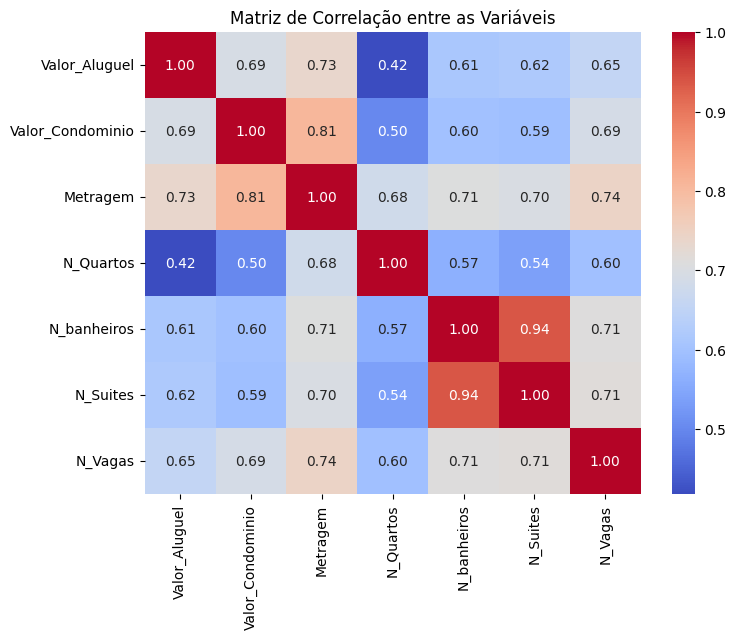

In [47]:
# Matriz de correlação com o Valor_Aluguel
correlacoes = df.corr(numeric_only=True)['Valor_Aluguel'].sort_values(ascending=False)
print(correlacoes)

plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlação entre as Variáveis')
plt.show()

A variável com maior correlação com `Valor_Aluguel` é **Metragem**, seguida de perto por `Valor_Condominio` e `N_Vagas`. `N_Quartos` é a que menos se correlaciona com o aluguel entre as variáveis analisadas. Como `Metragem` tem a correlação mais forte, é ela que será usada no modelo de regressão linear simples.


B) Durante a aula, por nossa base ser pequena e demonstrativa não realizamos a separação de treino e teste, porém para as atividades do dia dia temos que fazer, nesse exercício separe treino e teste.

Lembre-se que primeiro separamos as variaveis dependentes X e depois Y, essa etapa deixarei para vocês abaixo:

In [48]:
X = df.drop('Valor_Aluguel', axis=1) #Separando X - Todas variáveis exceto valor_aluguel
y = df['Valor_Aluguel'] #Separando Y (Apenas variavel valor_aluguel)

Dica: Para separar em treino e teste usamos o train_test_split, como visto nas aulas de pré modelagem.

In [49]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
print(f'y_train: {y_train.shape} | y_test: {y_test.shape}')

X_train: (4599, 6) | X_test: (1972, 6)
y_train: (4599,) | y_test: (1972,)


# 3 - Treine um modelo de regressão Linear simples

A) Vamos utilizar apenas X_train e y_train para rodar um modelo de regressão linea simples e para isso usaremos apenas uma váriavel, a váriavel metragem.

In [50]:
X_simples_train = X_train[['Metragem']]  # Variável independente (maior correlação)
y_simples_train = y_train  # Variável dependente

In [51]:
modelo_simples = LinearRegression()
modelo_simples.fit(X_simples_train, y_simples_train)

LinearRegression()

B) Plote o intercept_ e coef_ e monte de forma extensa a equação da reta.

In [52]:
intercepto = modelo_simples.intercept_
coeficiente = modelo_simples.coef_[0]

print(f'Intercepto: {intercepto:.2f}')
print(f'Coeficiente (Metragem): {coeficiente:.2f}')
print(f'Equação: Valor_Aluguel = {intercepto:.2f} + {coeficiente:.2f} * Metragem')

Intercepto: -65.95
Coeficiente (Metragem): 34.23
Equação: Valor_Aluguel = -65.95 + 34.23 * Metragem


Nossa equação seria: `Valor_Aluguel = -65,95 + 34,23 * Metragem`

Ou seja, para cada metro quadrado a mais, o aluguel esperado sobe cerca de R$ 34,23, partindo de um intercepto de -R$ 65,95 (valor sem significado prático isolado, já que nenhum imóvel tem 0 m², mas necessário para o ajuste da reta).

c) Calcule o R quadrado para o modelo de treinamento. Não esqueça de avaliar e trazer em formato de insight se esse resultado te parece bom ou não.

In [53]:
r2_treino_simples = modelo_simples.score(X_simples_train, y_simples_train)
print(f'R² de treino (modelo simples): {r2_treino_simples:.4f}')

R² de treino (modelo simples): 0.5184


D) Plote o gráfico da reta de regressão encontrada e traga insights acerca da dispersão dos pontos e ajuste da reta.

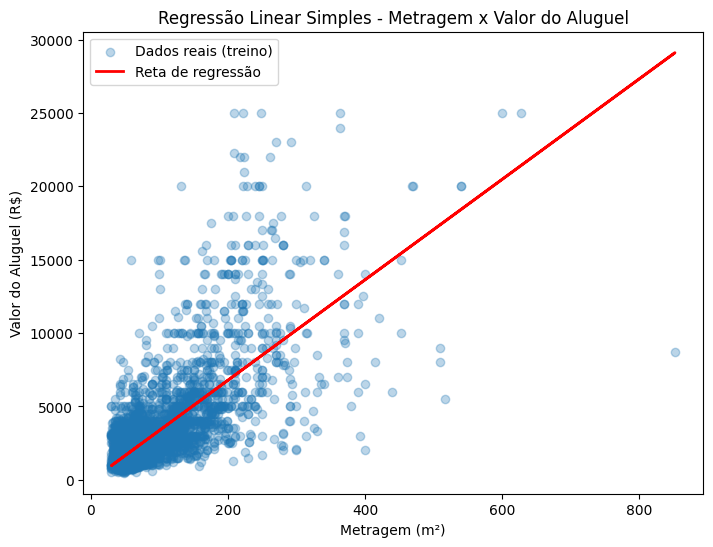

In [54]:
plt.figure(figsize=(8, 6))
plt.scatter(X_simples_train, y_simples_train, alpha=0.3, label='Dados reais (treino)')
plt.plot(X_simples_train, modelo_simples.predict(X_simples_train), color='red', linewidth=2, label='Reta de regressão')
plt.xlabel('Metragem (m²)')
plt.ylabel('Valor do Aluguel (R$)')
plt.title('Regressão Linear Simples - Metragem x Valor do Aluguel')
plt.legend()
plt.show()

**Insight:** a reta acompanha bem a tendência central dos pontos, mas a dispersão em torno dela cresce nas metragens maiores, o que é esperado já que apenas uma variável (Metragem) não captura todos os fatores que formam o preço (condomínio, vagas, suítes etc.). Isso é coerente com o R² moderado do modelo simples: ele explica boa parte da variação do aluguel, mas deixa uma faixa de erro considerável para imóveis fora do padrão médio.

E) Para finalizar vamos aplicar o modelo a base de teste. Essa etapa é nova, então agora vocês avaliaram como o modelo treinado se saiu com a base de testes.
Para isso altere no código abaixo o nome do seu modelo de regressão:

In [55]:
X_simples_test = X_test[['Metragem']]  # Variável independente (características)
y_simples_test = y_test  # Variável dependente

In [56]:
# Usando o modelo treinado para fazer previsões sobre os dados de teste
previsoes = modelo_simples.predict(X_simples_test)

# Avaliando o desempenho do modelo usando métricas como o R²
r2_teste_simples = modelo_simples.score(X_simples_test, y_simples_test)

print("Coeficiente de Determinação (R²) nos Dados de Teste:", r2_teste_simples)

Coeficiente de Determinação (R²) nos Dados de Teste: 0.5811291928211326


Se o valor do coeficiente de determinação (R²) para os dados de treinamento for melhor (ou seja, mais próximo de 1) do que o R² para os dados de teste, isso sugere que o modelo está superajustado aos dados de treinamento. Isso significa que o modelo pode estar se ajustando muito bem aos padrões específicos nos dados de treinamento, mas pode não generalizar bem para novos dados que não foram vistos durante o treinamento.

Por outro lado, se o R² para os dados de teste for melhor do que o R² para os dados de treinamento, isso pode ser indicativo de que o modelo está subajustado. Isso significa que o modelo não está se ajustando adequadamente aos padrões nos dados de treinamento e não está capturando a relação entre as variáveis independentes e dependentes de forma eficaz.

Idealmente, gostaríamos que o valor do R² fosse consistente entre os dados de treinamento e teste, indicando que o modelo é capaz de generalizar bem para novos dados. Se houver uma grande diferença entre os valores de R² para os dados de treinamento e teste, isso sugere que o modelo pode precisar de ajustes para melhorar sua capacidade de generalização.

F) Avalie com suas palavras o valor do r quadrado encontrado no treino e no teste.

O modelo simples obteve R² de 0,5184 no treino e 0,5811 no teste. O R² de teste ficou um pouco **acima** do R² de treino, o que descarta overfitting (se houvesse overfitting, o treino teria R² bem maior que o teste). A diferença também não é grande o suficiente para indicar underfitting real: é mais provável que seja efeito da divisão aleatória dos dados (o `test_size=0.3` pode ter concentrado no teste uma faixa de imóveis onde a metragem explica melhor o aluguel). De forma geral, um R² em torno de 0,52 a 0,58 mostra que a metragem sozinha explica bem mais da metade da variação do aluguel, mas ainda deixa uma parte relevante sem explicar, o que já era esperado ao usar apenas uma variável.

# 4 - Aplicação do modelo de regressão linear multipla!

A) Vamos refazer os passos anteriores porém para regressão multipla, com todas variáveis dependentes. Comece separando a base treino e teste, dessa vez com todas variáveis para X.

Aqui é só refazer os passos do exercicio 3 porém ao invés de trazer para X apenas metragem, você deve trazer todas colunas (exceto a valor do aluguel).

In [57]:
# X_train e X_test já contêm todas as variáveis independentes (foram criados
# na célula de split geral, antes de isolarmos a Metragem para o modelo simples).
# Não é necessário separar novamente: basta confirmar o formato.
print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
print(f'Colunas usadas: {list(X_train.columns)}')

X_train: (4599, 6) | X_test: (1972, 6)
Colunas usadas: ['Valor_Condominio', 'Metragem', 'N_Quartos', 'N_banheiros', 'N_Suites', 'N_Vagas']


B) Faça o modelo de regressão linear multipla aplicado só a base de treino.

In [58]:
modelo_multiplo = LinearRegression()
modelo_multiplo.fit(X_train, y_train)

coeficientes = pd.Series(modelo_multiplo.coef_, index=X_train.columns)
print(f'Intercepto: {modelo_multiplo.intercept_:.2f}')
print('Coeficientes:')
print(coeficientes)

Intercepto: 510.48
Coeficientes:
Valor_Condominio      0.716851
Metragem             21.209034
N_Quartos          -627.945519
N_banheiros          46.452004
N_Suites            444.671319
N_Vagas             614.621900
dtype: float64


C) Traga o valor do R quadrado e avalie o valor encontrado.

In [59]:
r2_treino_multiplo = modelo_multiplo.score(X_train, y_train)
print(f'R² de treino (modelo múltiplo): {r2_treino_multiplo:.4f}')

R² de treino (modelo múltiplo): 0.5878


D) Para finalizar aplique o modelo a base de teste e traga o r quadrado de teste.
Dica: Você pode usar os códigos do exercício anterior.

In [60]:
r2_teste_multiplo = modelo_multiplo.score(X_test, y_test)
print(f'R² de teste (modelo múltiplo): {r2_teste_multiplo:.4f}')

R² de teste (modelo múltiplo): 0.6536


E) Compare os r quadrados encontrados pela regressão linear e pela regressão múltipla. Qual modelo te parece melhor? Por qual motivo acredita que isso ocorreu?

Comparando os dois modelos:

| Modelo | R² treino | R² teste |
|---|---|---|
| Regressão simples (Metragem) | 0,5184 | 0,5811 |
| Regressão múltipla (todas as variáveis) | 0,5878 | 0,6536 |

O modelo múltiplo teve o melhor desempenho nas duas bases. Isso faz sentido porque o aluguel não depende só da metragem: variáveis como valor do condomínio, vagas e suítes também têm correlação relevante com o preço (vistas na etapa de correlação), então incluí-las dá ao modelo mais informação para prever o valor. O ganho de R² (cerca de 7 pontos percentuais no teste) mostra que essas variáveis adicionam poder explicativo real, e não é um ganho artificial de overfitting, já que o R² de teste do modelo múltiplo também subiu e continuou próximo do R² de treino. Olhando os coeficientes, `N_Quartos` aparece com peso negativo, o que sugere que, mantendo a metragem fixa, apartamentos com mais quartos (logo, cômodos menores) tendem a ser um pouco mais baratos, um padrão plausível no mercado de aluguel.